In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("../../../").resolve()
STANDARD_OUTPUT = PROJECT_DIR / "data" / "results" / "out_standard"
OPTIMIZED_OUTPUT = PROJECT_DIR / "data" / "results" / "out_optimized"

In [ ]:
def compare_and_print(df_std, df_opt, name):
    print(f"--- Comparing {name} ---")
    try:
        pd.testing.assert_frame_equal(df_std, df_opt, check_exact=True)
        print("EXACT MATCH ")
    except AssertionError as e:
        print("DIFFERENCE FOUND ")
        
        # Find numeric columns for comparison
        numeric_cols = df_std.select_dtypes(include=['number']).columns
        if not numeric_cols.empty:
            deviations = []
            for col in numeric_cols:
                std_vals = df_std[col]
                opt_vals = df_opt[col]
                
                # Calculate percent deviation: abs(std - opt) / abs(std) * 100
                # Only calculate where std is not zero
                mask = std_vals != 0
                if mask.any():
                    percent_diff = (abs(std_vals[mask] - opt_vals[mask]) / abs(std_vals[mask])) * 100
                    avg_dev = percent_diff.mean()
                    deviations.append(f"{col}: {avg_dev:.12f}% ")
            
            if deviations:
                print( "Average Percent Deviation: ")
                for dev in deviations:
                    print(f"  - {dev} ")
            else:
                print(e)
        else:
            print(e)

# Job 1: Trips per Borough
std1 = pd.read_csv(STANDARD_OUTPUT / "1_trips_per_borough.csv").sort_values("borough").reset_index(drop=True)
opt1 = pd.read_csv(OPTIMIZED_OUTPUT / "1_trips_per_borough.csv").sort_values("borough").reset_index(drop=True)

# Job 2 & 4
opt_2_4 = pd.read_csv(OPTIMIZED_OUTPUT / "2-4_trips_and_speed_per_hour.csv")
opt2 = opt_2_4[["hour", "trips"]].sort_values("hour").reset_index(drop=True)
opt4 = opt_2_4[["hour", "avg_speed"]].sort_values("hour").reset_index(drop=True)

# Job 2: Trips per Hour
std2 = pd.read_csv(STANDARD_OUTPUT / "2_trips_per_hour.csv").sort_values("hour").reset_index(drop=True)

# Job 3: Trips per Month
months_order = ["JANUARY", "FEBRUARY", "MARCH", "APRIL", "MAY", "JUNE", "JULY", "AUGUST", "SEPTEMBER", "OCTOBER", "NOVEMBER", "DECEMBER"]
std3 = pd.read_csv(STANDARD_OUTPUT / "3_trips_per_month.csv")
std3['month'] = pd.Categorical(std3['month'], categories=months_order, ordered=True)
std3 = std3.sort_values("month").reset_index(drop=True)
opt3 = pd.read_csv(OPTIMIZED_OUTPUT / "3_trips_per_month.csv")
opt3['month'] = pd.Categorical(opt3['month'], categories=months_order, ordered=True)
opt3 = opt3.sort_values("month").reset_index(drop=True)

# Job 4: Average Speed
std4 = pd.read_csv(STANDARD_OUTPUT / "4_average_speed.csv").sort_values("hour").reset_index(drop=True)

# Job 5: Average Tips by Borough
std5 = pd.read_csv(STANDARD_OUTPUT / "5_average_tips_by_borough.csv").sort_values("destination_borough").reset_index(drop=True)
opt5 = pd.read_csv(OPTIMIZED_OUTPUT / "5_average_tips_by_borough.csv").sort_values("destination_borough").reset_index(drop=True)

--- Comparing Job 1: Trips per Borough ---
EXACT MATCH 


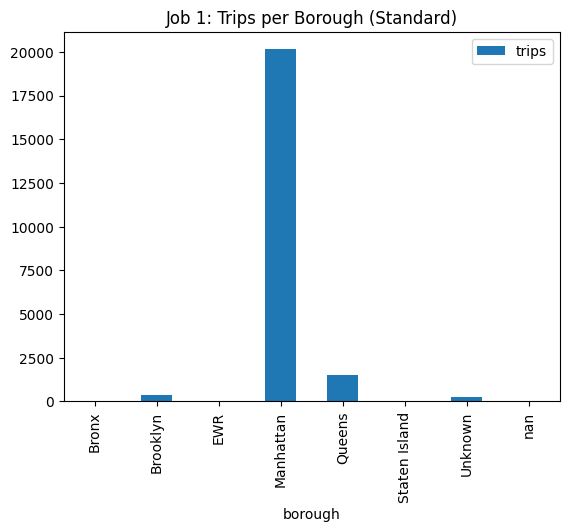

In [3]:
compare_and_print(std1, opt1, "Job 1: Trips per Borough")
std1.plot(kind="bar", x="borough", y="trips", title="Job 1: Trips per Borough (Standard)")
plt.show()

--- Comparing Job 2: Trips per Hour ---
EXACT MATCH 


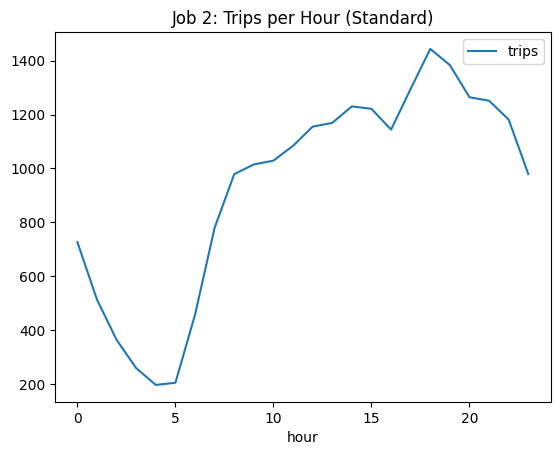

In [4]:
compare_and_print(std2, opt2, "Job 2: Trips per Hour")
std2.plot(kind="line", x="hour", y="trips", title="Job 2: Trips per Hour (Standard)")
plt.show()

--- Comparing Job 3: Trips per Month ---
EXACT MATCH 


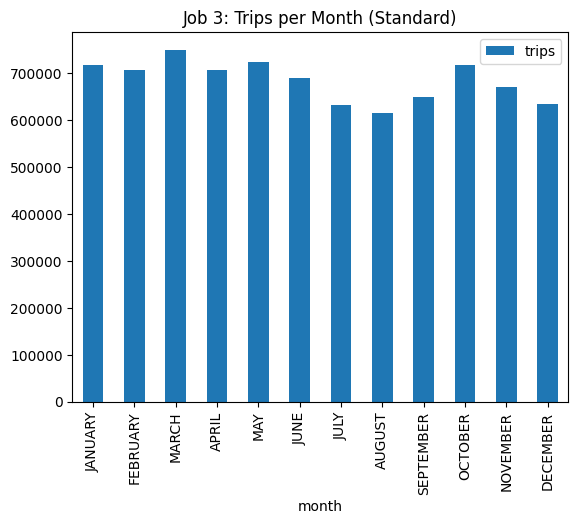

In [5]:
compare_and_print(std3, opt3, "Job 3: Trips per Month")
std3.plot(kind="bar", x="month", y="trips", title="Job 3: Trips per Month (Standard)")
plt.show()

--- Comparing Job 4: Average Speed ---
DIFFERENCE FOUND 
Average Percent Deviation: 
  - hour: 0.000000000000%  
  - avg_speed: 0.000000000000%  


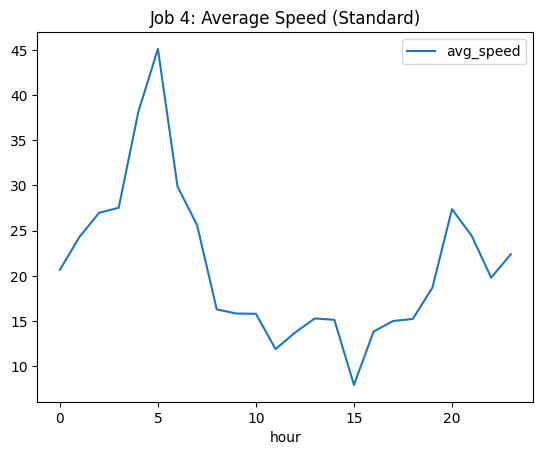

In [6]:
compare_and_print(std4, opt4, "Job 4: Average Speed")
std4.plot(kind="line", x="hour", y="avg_speed", title="Job 4: Average Speed (Standard)")
plt.show()

--- Comparing Job 5: Average Tips by destination Borough ---
DIFFERENCE FOUND 
Average Percent Deviation: 
  - avg_tips: 0.000000000091%  


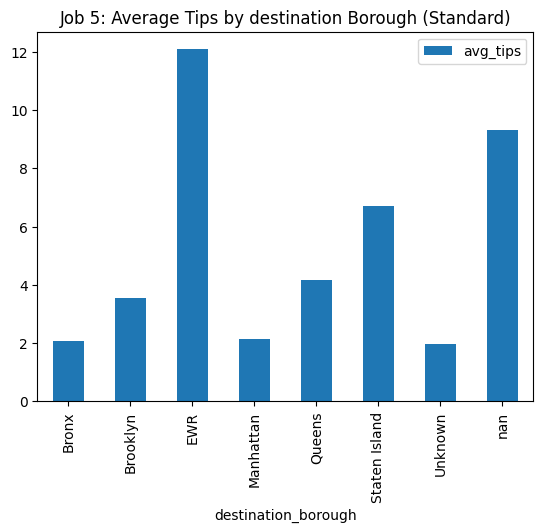

In [7]:
compare_and_print(std5, opt5, "Job 5: Average Tips by destination Borough")
std5.plot(kind="bar", x="destination_borough", y="avg_tips", title="Job 5: Average Tips by destination Borough (Standard)")
plt.show()